# Semester 4 Coding Portfolio Part 5: Regularization for Trees

This notebook covers the following topics:
 - Decision Trees: CART
 - Pruning Decision Trees
 - Resampling: Undersampling, Oversampling and SMOTENC
 - Random Forest & XGBoost
 - Ensemble Modeling: Bagging, Stacking and Voting

This notebook is expected to take around 20 hours to complete:
 - 4 hours for the formative part
 - 6 hours of self-study on the topics covered by this notebook
 - 10 hours for the summative part of this notebook

Like all notebooks in this portfolio, it is split into two sections:
 - Formative 
 - Summative

<b>Formative section</b><br>
Simply complete the given functions! You may ask for help from fellow students and TAs on this section, and solutions might be provided later on.

<b>Summative section</b><br>
In this section, you are asked to do original work with little guidance, based on the skills you learned in the formative part (as well as lectures and workshops).
This section is graded not just on passing automated tests, but also on quality, originality, and effort (see assessment criteria in the assignment description).

In [72]:
# TODO: Please enter your student number here
STUDENT_NUMBER = 0

# Formative Section
Please do not add additional cells to this section, and do not delete given code. Simply fill out the code or answer questions in the given cells.

### Part 0: Load data
This notebook is divided into two parts. In the first half, a decision tree is applied to Heart Disease UCI dataset and the decision tree is regularized by different pruning methods. A plot of Model performance will be utilized to examine overfitting and underfitting.

In the second half, crucial resampling methods and ensemble methods are introduced. Another dataset, UCI Adult dataset, will be utilized.

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

from scipy.stats import beta, norm, bernoulli

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from decimal import Decimal
from collections import Counter

In [74]:
# Implement a function to plot the confusion matrix.
# The model should contain a prediction function called predict().
# The function is only implemented to be a convenient plotting method,
# it is not suitable for general use.
# This is only for binary classification
def print_plot_confusion_matrix(modelname,X_test,y_test):
    # Making predictions
    predictions = modelname.predict(X_test)
    
    # Calculate and print the accuracy
    accuracy = accuracy_score(y_test, predictions)
    print(f"Accuracy: {accuracy:.4f}")

    # Compute confusion_matrix
    labels_confu = np.unique(np.concatenate((y_test, predictions)))
    cm = confusion_matrix(y_test, predictions, labels=labels_confu)

    # Print FNR and FPR
    TN, FP, FN, TP = cm.ravel()
    FNR = FN / (FN + TP)
    FPR = FP / (FP + TN)
    print("False Negative Rate (FNR):", FNR, "&& False Positive Rate (FPR):", FPR)
    
    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_confu)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for model {modelname.__class__.__name__}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return FNR, FPR

## **1.** Decision Trees: CART

In this section, you will use the CART algorithm in sklearn package to build and interpret a decision tree classifier. Apply this classifier to a real-world dataset, compute confusion matrix, and then intepret the plotted decision tree structure.

The Heart Disease UCI dataset is a well-known dataset from the UCI Machine Learning Repository. It contains data used to predict the presence of heart disease in patients.

If you want to know the features, here is some information on the variables in this dataset:
1. age: age in years
2. sex: sex (1 = male; 0 = female)
3. cp: chest pain type:
    - Value 1: typical angina
    - Value 2: atypical angina
    - Value 3: non-anginal pain
    - Value 4: asymptomatic
4. trestbps: resting blood pressure (in mm Hg on admission to the hospital)
5. chol: serum cholestoral in mg/dl
6. fbs: (fasting blood sugar > 120 mg/dl)  (1 = true; 0 = false)
7. restecg: resting electrocardiographic results
    - Value 0: normal
    - Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    - Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria
8. thalach: maximum heart rate achieved   
9. exang: exercise induced angina (1 = yes; 0 = no)
10. oldpeak = ST depression induced by exercise relative to rest
11. slope: the slope of the peak exercise ST segment
    - Value 1: upsloping
    - Value 2: flat
    - Value 3: downsloping
12. ca: number of major vessels (0-3) colored by flourosopy        
13. thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
14. num: diagnosis of heart disease (angiographic disease status)
    - Value 0: < 50% diameter narrowing, which is no disease.
    - Value more than 0: > 50% diameter narrowing (in any major vessel), which indicates disease.
   
The dependent variable is the last one which indicates the presence or absence of the disease.

Load the "Heart Disease UCI" dataset & remove missing values. We don't focus on pre-processing this time.

In [75]:
# import data & add column names
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
]
df = pd.read_csv('processed.cleveland.data', names=column_names, header=None)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [76]:
# drop missing values
df.replace('?', np.nan, inplace=True)  # missing entries are marked with '?'
df.dropna(inplace=True)

In [77]:
# Split the DataFrame into features and target
X = df.drop('num', axis=1)  # Drop the target
y = df['num']  # Target column

# Split the dataset into training and testing sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print([type(X_train.iloc[0,i]) for i in range(len(X_train.columns))])

[<class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'str'>, <class 'str'>]


Now we will apply a CART model.

Note: We always need to check the data type beforehand. If we are using ID3, we need to discretize the continuous variables. While CART prefers continuous variables, it allows both categorical and numeric variables.

In [78]:
# Create a DecisionTreeClassifier object
cart_model = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
cart_model.fit(X_train, y_train);

Now let's make some predictions on the test set to see the result:

Accuracy: 0.4833


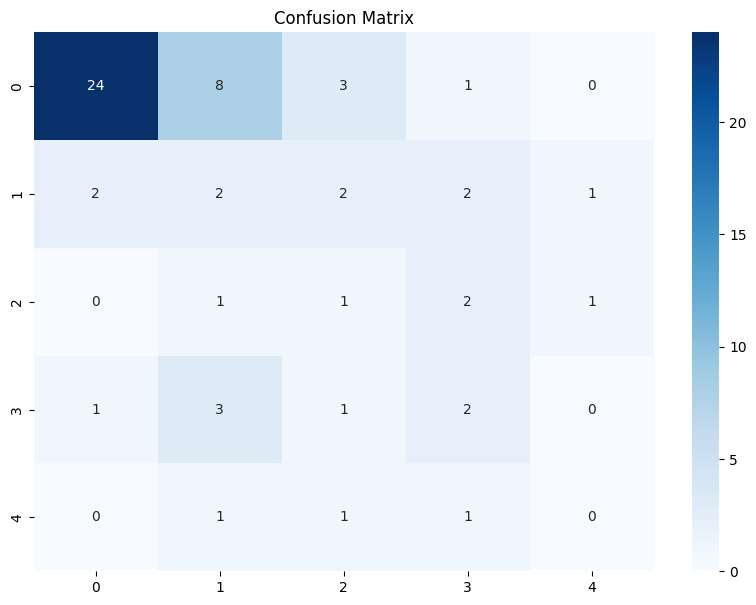

In [79]:
# Making predictions
predictions = cart_model.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")

# Generate and plot the confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2, 3, 4], yticklabels=[0, 1, 2, 3, 4])
plt.title('Confusion Matrix')
plt.show()

Finally, we visualize the decision tree:

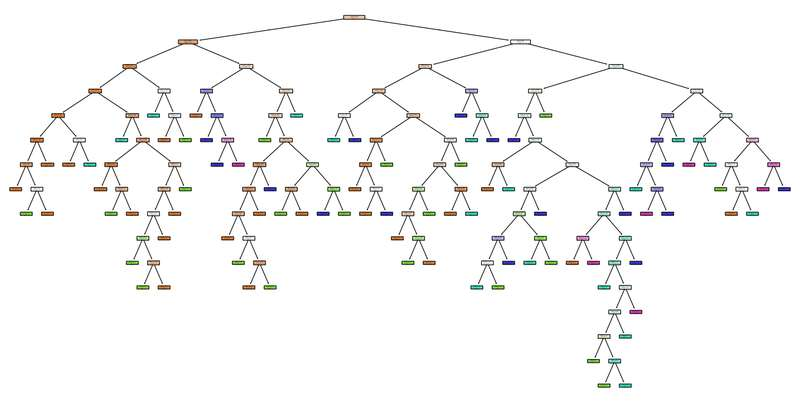

In [80]:
plt.figure(figsize=(20,10))
plot_tree(cart_model, 
          filled=True, 
          rounded=True, 
          class_names=['0', '1', '2', '3', '4'],  # Update class names as appropriate
          feature_names=list(X_train.columns))       # Ensure X_train.columns is accessible
plt.show()

According to the confusion matrix, our model is highly biased. Our prediction is mainly focusing on the class "0". In fact, all values other than 0 are indicative of having disease, and based on this information, we can turn problem into a binary classification. We map the values and do the decision tree again.

Note: there are other solutions. For simplicity, we use the binary classification here.

In [81]:
# Giving num (diagnosis of heart disease) more descriptive names
num_replacements = {0: 'no disease', 
                    1: 'disease',
                    2: 'disease',
                    3: 'disease',
                    4: 'disease',
                    5: 'disease'}
df['bin_class'] = df['num'].replace(num_replacements)

# Split the DataFrame into features and target
X = df.drop(['num','bin_class'], axis=1)  # Drop the target
y = df['bin_class']  # Target column

# Split the dataset into training and testing sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print([type(X_train.iloc[0,i]) for i in range(len(X_train.columns))])

[<class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'numpy.float64'>, <class 'str'>, <class 'str'>]


In [82]:
# Create a DecisionTreeClassifier object
cart_model = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
cart_model.fit(X_train, y_train);

Accuracy: 0.7833


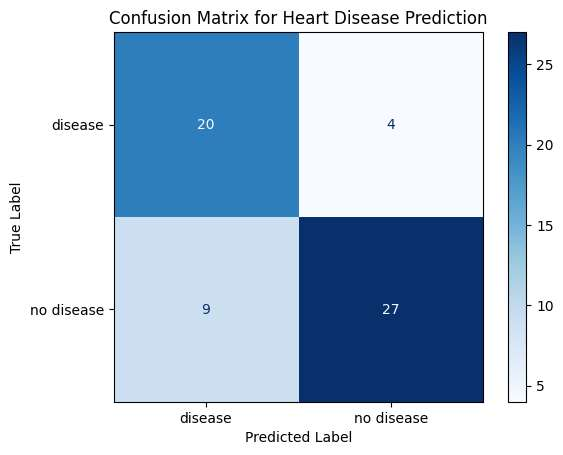

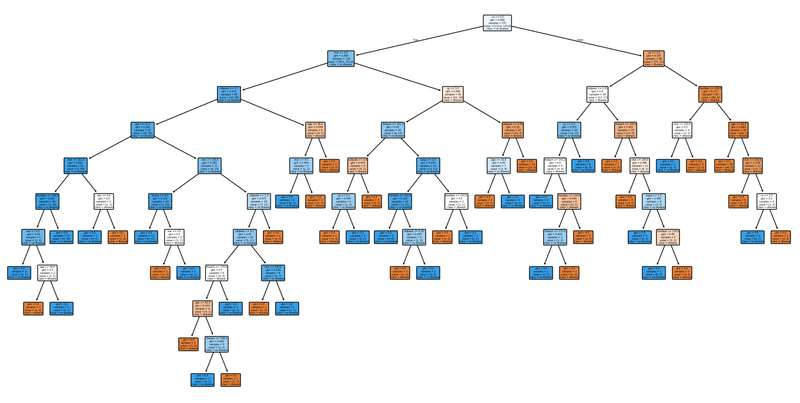

In [83]:
def predict_plot_metric_and_tree(modelname,X_test,y_test):
    # Making predictions
    predictions = modelname.predict(X_test)
    
    # Calculate and print the accuracy
    accuracy = accuracy_score(y_test, predictions)
    print(f"Accuracy: {accuracy:.4f}")
    
    # Compute confusion matrix
    labels_confu = np.unique(np.concatenate((y_test, predictions)))
    cm = confusion_matrix(y_test, predictions, labels=labels_confu)
    
    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_confu)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix for Heart Disease Prediction')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    # Plot the tree
    plt.figure(figsize=(20,10))
    plot_tree(modelname, 
              filled=True, 
              rounded=True, 
              class_names=list(map(str, modelname.classes_)),  # Update class names as appropriate
              feature_names=list(X_test.columns))       # Ensure X_test.columns is accessible
    plt.show()

# Apply the function
predict_plot_metric_and_tree(cart_model,X_test,y_test)

## **2.** Pruning Decision Trees

Pruning is a technique for modifying models to achieve regularization. We will introduce three pruning methods. They can all be implemented simply by changing the function arguments.

Accuracy: 0.7500


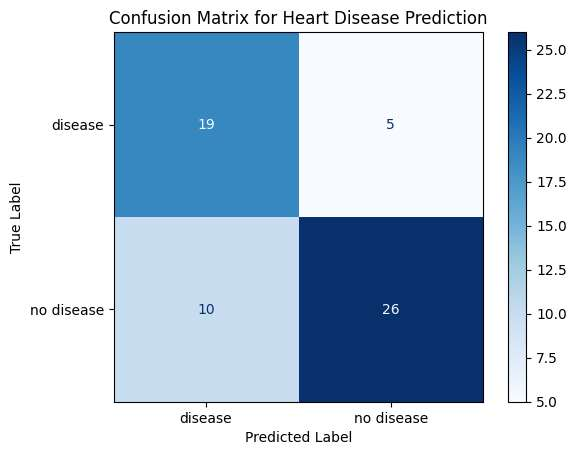

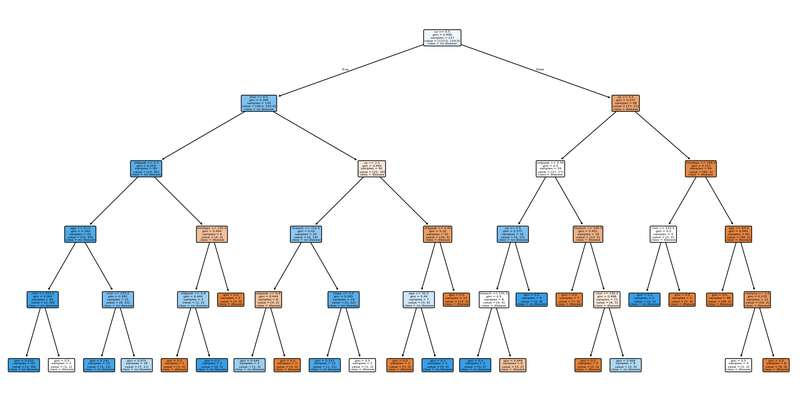

In [84]:
# Method 1: Limiting the maximum depth of the tree
max_depth_model = DecisionTreeClassifier(max_depth=5)
max_depth_model.fit(X_train, y_train)
predict_plot_metric_and_tree(max_depth_model,X_test,y_test)

Accuracy: 0.8000


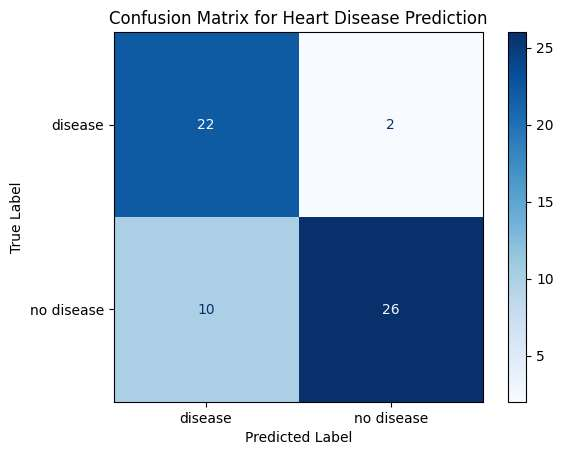

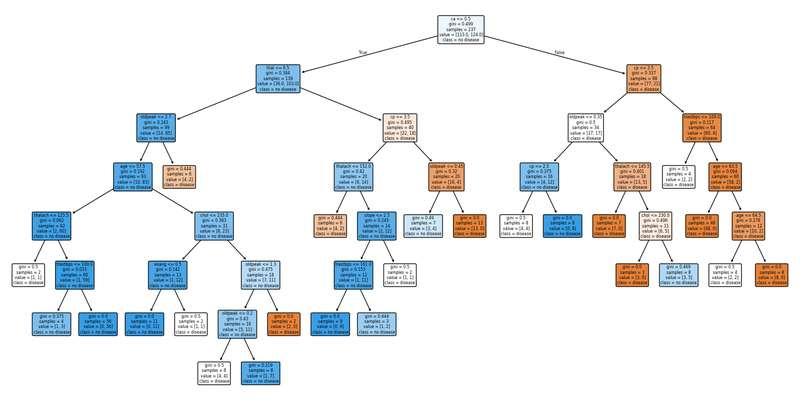

In [85]:
# Method 2: Setting the minimum number of samples required to split an internal node
min_samples_split_model = DecisionTreeClassifier(min_samples_split=10)
min_samples_split_model.fit(X_train, y_train)
predict_plot_metric_and_tree(min_samples_split_model,X_test,y_test)

Method 3 is cost-complexity pruning. This method gives us a easy way to contral the model complexity to become the one we want. In some cases, we may need to try several times to find the best value for CCP-Alpha. Here we use the value of index 6 (Index 6: ccp_alpha = 0.005625879043600562), it is a result from the later part.

Index 0: ccp_alpha = 0.0
Index 1: ccp_alpha = 0.002766057196436945
Index 2: ccp_alpha = 0.003616636528028934
Index 3: ccp_alpha = 0.003894839337877311
Index 4: ccp_alpha = 0.004017512817022814
Index 5: ccp_alpha = 0.005438349742147208
Index 6: ccp_alpha = 0.005625879043600562
Index 7: ccp_alpha = 0.005625879043600562
Index 8: ccp_alpha = 0.005625879043600563
Index 9: ccp_alpha = 0.005625879043600563
Index 10: ccp_alpha = 0.006065400843881857
Index 11: ccp_alpha = 0.0066451769953199125
Index 12: ccp_alpha = 0.0076183778715424285
Index 13: ccp_alpha = 0.007665260196905771
Index 14: ccp_alpha = 0.008438818565400845
Index 15: ccp_alpha = 0.008892518488271856
Index 16: ccp_alpha = 0.009724733775366687
Index 17: ccp_alpha = 0.013502109704641347
Index 18: ccp_alpha = 0.014870358684160256
Index 19: ccp_alpha = 0.015939990623534926
Index 20: ccp_alpha = 0.021097046413502116
Index 21: ccp_alpha = 0.03586497890295359
Index 22: ccp_alpha = 0.0401355018785125
Index 23: ccp_alpha = 0.134566277437911

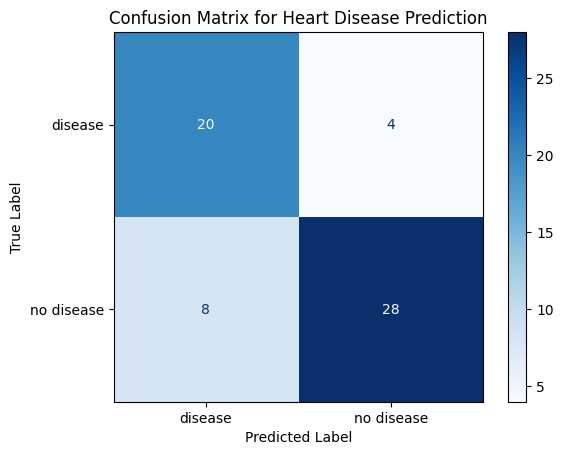

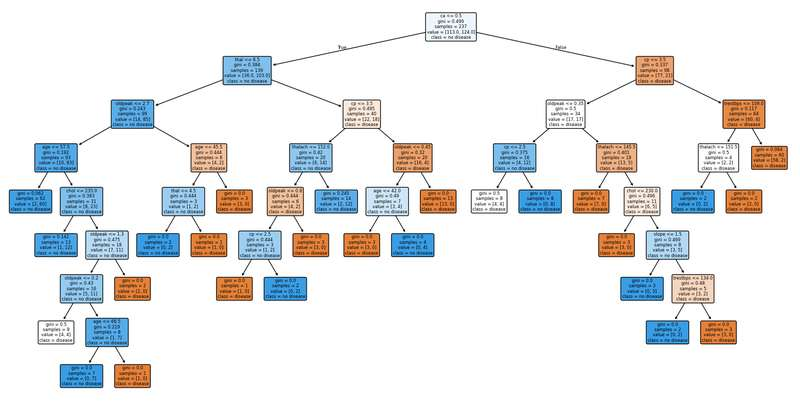

In [86]:
# Method 3: Using cost complexity pruning
# You need to have an initial tree to do so. Run the initial tree in part 1 to get cart_model.
path = cart_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alpha_model = DecisionTreeClassifier(ccp_alpha=ccp_alphas[6])

ccp_alpha_model.fit(X_train, y_train)

print("\n".join([f"Index {index}: ccp_alpha = {ccp_alpha}" for index, ccp_alpha in enumerate(ccp_alphas)]))
predict_plot_metric_and_tree(ccp_alpha_model,X_test,y_test)

In this part, we will plot the model performance to check if overfitting or underfitting has occurred. This also helps us to choose the value for CCP-Alpha.

You can check them using other methods. In the part of regularization, our goal is to find a suitable complexity at which the model is neither overfitted nor underfitted.

Based on the learning curve we have learned last semester, we can use training accuracy and validation accuracy to represent model performance. Now let's compute them as the y-axis and effective alpha as the x-axis.

In [87]:
# Check if ccp_alphas is well defined
assert np.array_equal(ccp_alphas, path.ccp_alphas)

# Exclude the maximum value which would prune the entire tree
ccp_alphas = ccp_alphas[:-1]

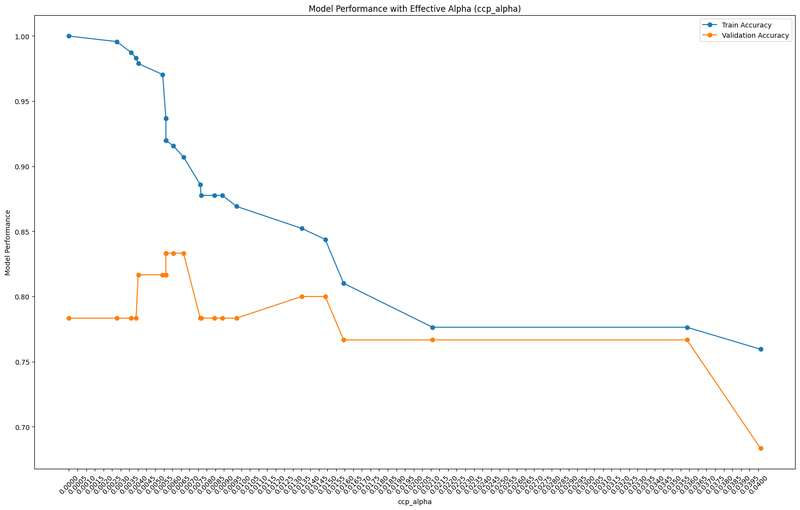

In [88]:
# Train trees using different ccp_alpha values and store their performance
train_scores = []
val_scores = []

for ccp_alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    tree.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, tree.predict(X_train)))
    val_scores.append(accuracy_score(y_test, tree.predict(X_test)))

# Plot the results
plt.figure(figsize=(20, 12))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train Accuracy')
plt.plot(ccp_alphas, val_scores, marker='o', label='Validation Accuracy')
plt.xticks(np.arange(ccp_alphas[0], ccp_alphas[-1], step=0.0005),rotation=45)
#plt.xlim(0.005,0.007)
plt.xlabel('ccp_alpha')
plt.ylabel('Model Performance')
plt.title('Model Performance with Effective Alpha (ccp_alpha)')
plt.legend()
plt.show()

In [89]:
# Evaluate and compare the models
print("Original CART Model Accuracy: ", cart_model.score(X_test, y_test))
print("Max Depth Model Accuracy: ", max_depth_model.score(X_test, y_test))
print("Min Samples Split Model Accuracy: ", min_samples_split_model.score(X_test, y_test))
print("CCP Alpha Model Accuracy: ", ccp_alpha_model.score(X_test, y_test))

Original CART Model Accuracy:  0.7833333333333333
Max Depth Model Accuracy:  0.75
Min Samples Split Model Accuracy:  0.8
CCP Alpha Model Accuracy:  0.8


Due to limited space, no other decision trees will be shown here. Decision tree is a simple, flexible and potential-rich approach. It can obviously be used not only for binary classification, but also for multi-class classification and for regression tasks (see DecisionTreeRegressor for more information).

## **3.** Resampling: Undersampling, Oversampling and SMOTENC

In this part, we'll explore several resampling methods to modify the sample distribution.

The task at hand will be predicting the sex of entries in UCI Adult dataset based on the independent variables. We will find that there is a class imbalance between both sexes and we will use resampling to solve this issue. In this notebook, we will explore three methods to handle this.

### Overview of the UCI Adult Dataset

The UCI Adult dataset, also known as the "Census Income" dataset, is a widely used dataset for machine learning tasks, particularly for classification problems. The dataset was extracted from the 1994 U.S. Census Bureau database and consists of approximately 48,842 instances. The primary goal is to predict whether an individual earns more than $50,000 per year based on various demographic attributes.

### Main Features

The dataset includes the following features:

1. **Age**: The age of the individual.
2. **Workclass**: The working class of the individual, such as Private, Self-emp-not-inc, Local-gov, etc.
3. **Fnlwgt**: Final weight, representing the number of people the census believes the entry represents.
4. **Education**: The highest level of education attained by the individual.
5. **Education-Num**: Numerical representation of education level.
6. **Marital-Status**: The marital status of the individual, such as Married-civ-spouse, Divorced, Never-married, etc.
7. **Occupation**: The occupation of the individual.
8. **Relationship**: The relationship of the individual to their household.
9. **Race**: The race of the individual.
10. **Sex**: The gender of the individual.
11. **Capital-Gain**: Capital gains income.
12. **Capital-Loss**: Capital loss.
13. **Hours-Per-Week**: The number of hours the individual works per week.
14. **Native-Country**: The native country of the individual.
15. **Income**: The variable indicating whether the individual earns more than $50,000 per year.

Typically, the feature “income” would be used as the dependent variable, but today, for demonstration purposes, we will use the feature “sex” as the dependent variable.

In the UCI Adult dataset, the "Sex" feature is encoded as follows:
- **0**: Female
- **1**: Male

This feature is crucial for understanding gender-related differences in income, work hours, and other socio-economic factors. In many analyses, researchers may explore whether gender has a significant impact on the likelihood of earning more than $50,000 per year and how it interacts with other features like education, occupation, and work hours.

Now let's start by importing the data.

You can use the following code to import the data.

You can also download the dataset by yourself. I can be done by using package aif360 and the function aif360.datasets.AdultDataset.

Note:

If you have compatibility problem between sklearn and imbalanced-learn. You can try the upgrade or downgrade them:

!pip install --upgrade scikit-learn imbalanced-learn

!pip install scikit-learn==1.5.2 imbalanced-learn==0.13.0

And restart the notebook.

In [90]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTEENN

In [91]:
# Define the file paths
desktop_path = os.path.expanduser("./")
data_file = os.path.join(desktop_path, "adult.data")
test_file = os.path.join(desktop_path, "adult.test")

# Define column names based on adult dataset documentation
column_names = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

# Load the dataset
# Note: Skip initial spaces in the columns and handle missing values ("?")
train_df = pd.read_csv(data_file, header=None, names=column_names, skipinitialspace=True, na_values="?")
test_df = pd.read_csv(test_file, header=0, names=column_names, skipinitialspace=True, na_values="?")

# Replace any instances of "unknown" with a missing value indicator (NaN)
train_df.replace("unknown", pd.NA, inplace=True)
test_df.replace("unknown", pd.NA, inplace=True)

# Drop any rows that contain missing values
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

# Mapping the 'sex' column: convert Female->0 and Male->1. 
# The conversion strips any extra spaces, converts to lowercase, and then maps.
mapping = {'female': 0, 'male': 1}

# Create y_train and y_test by using the "sex" column
y_train = train_df['sex'].str.strip().str.lower().map(mapping)
y_test  = test_df['sex'].str.strip().str.lower().map(mapping)

# Create X_train and X_test by dropping the "sex" column from the data
X_train = train_df.drop(columns=["sex"])
X_test  = test_df.drop(columns=["sex"])

# Optionally, display some results to verify
print(X_train.head())
print(y_train.unique())
print(train_df.shape)
print(test_df.shape)

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race  capital-gain  \
0       Never-married       Adm-clerical  Not-in-family  White          2174   
1  Married-civ-spouse    Exec-managerial        Husband  White             0   
2            Divorced  Handlers-cleaners  Not-in-family  White             0   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black             0   
4  Married-civ-spouse     Prof-specialty           Wife  Black             0   

   capital-loss  hours-per-week native-country income  
0             0              40  United-States  <=50K  
1             0              13  U

In [92]:
# Check data types, should have clear distinction between categorical and numerical
X_train.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

Let's train a model without resampling for later comparison.

Accuracy: 0.8100
False Negative Rate (FNR): 0.14250517394303736 && False Positive Rate (FPR): 0.28821493995522085


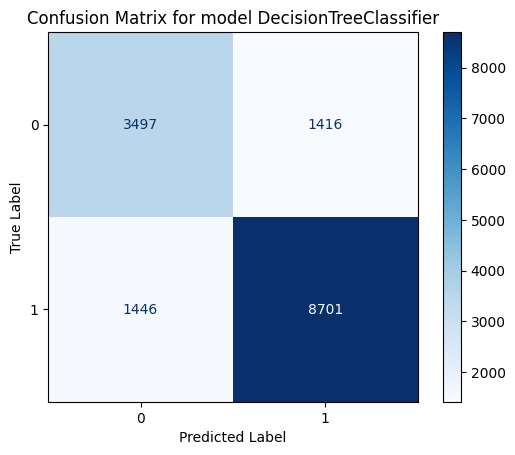

DecisionTreeClassifier(random_state=42)

In [93]:
def train_plain_CART_print_plot(X_train, X_test, y_train, y_test):
    # Train a simple CART and use the function print_plot_confusion_matrix
    cart_model = DecisionTreeClassifier(random_state=42)
    cart_model.fit(X_train, y_train)
    print_plot_confusion_matrix(cart_model, X_test, y_test)
    return cart_model

def train_CART_onehot_print_plot(X_train, X_test, y_train, y_test):
    """
    This function applies one hot encoding to the training and test features,
    then calls the train_plain_CART_print_plot function to train and evaluate a CART model.
    """
    # Identify categorical columns (assuming they are of type 'object')
    categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

    # Apply one-hot encoding using pandas get_dummies; drop_first to avoid dummy variable trap.
    X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
    X_test_encoded  = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

    # Align the dataframes so they have the same columns; fill missing dummy columns with 0.
    X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

    # Train CART using the encoded features.
    return train_plain_CART_print_plot(X_train_encoded, X_test_encoded, y_train, y_test)

train_CART_onehot_print_plot(X_train, X_test, y_train, y_test)

Let's start oversampling and undersampling.

Accuracy: 0.8118
False Negative Rate (FNR): 0.19040110377451464 && False Positive Rate (FPR): 0.18359454508446976


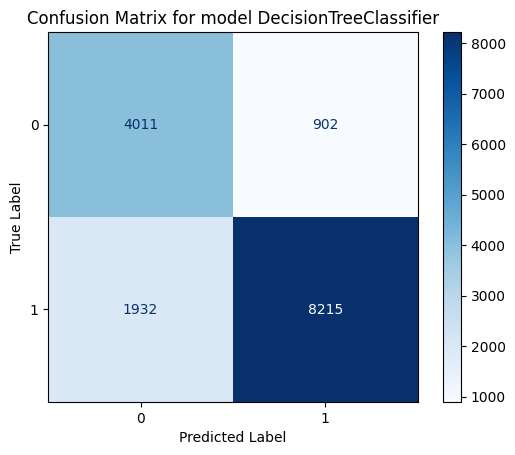

DecisionTreeClassifier(random_state=42)

In [94]:
# Method 1: Undersampling using RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

train_CART_onehot_print_plot(X_train_rus, X_test, y_train_rus, y_test)

Accuracy: 0.8059
False Negative Rate (FNR): 0.14536316152557407 && False Positive Rate (FPR): 0.29472827193161


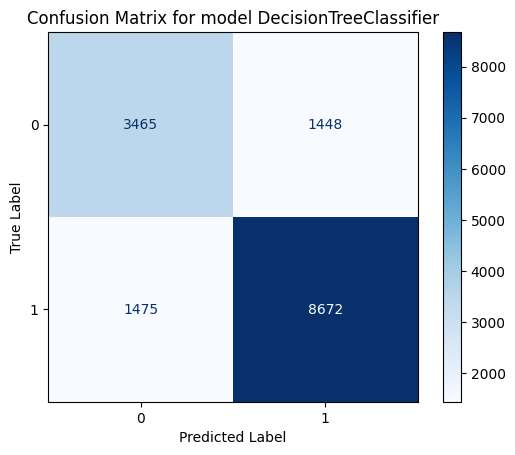

DecisionTreeClassifier(random_state=42)

In [95]:
# Method 2: Oversampling using RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

train_CART_onehot_print_plot(X_train_ros, X_test, y_train_ros, y_test)

In this part, we use SMOTENC to carry out the oversampling. SMOTENC is relatively slow because it has to work with numeric and categorical data at the same time. If all your data is numeric or categorical, you should use SMOTE or SMOTEN, respectively.

Accuracy: 0.8086
False Negative Rate (FNR): 0.1610328175815512 && False Positive Rate (FPR): 0.2540199470791777


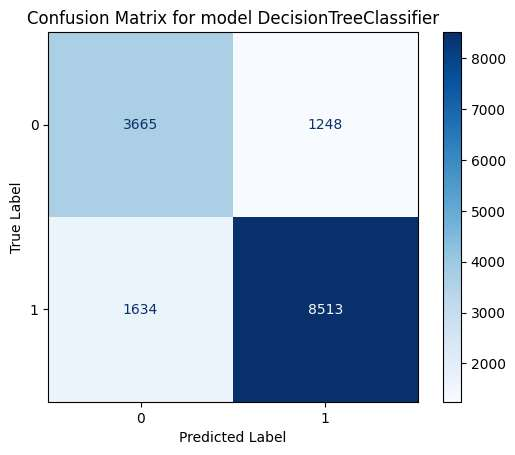

DecisionTreeClassifier(random_state=42)

In [96]:
# Method 3: Oversampling using SMOTENC

# Identify categorical columns by checking for the 'object' dtype.
categorical_columns = X_train.select_dtypes(include=['object']).columns.tolist()
categorical_feature_indices = [X_train.columns.get_loc(col) for col in categorical_columns]
        
smotenc = SMOTENC(categorical_features=categorical_feature_indices, random_state=42)
X_train_smotenc, y_train_smotenc = smotenc.fit_resample(X_train, y_train)

train_CART_onehot_print_plot(X_train_smotenc, X_test, y_train_smotenc, y_test)

Now, we want to control for the sample size of the minority group. We want it to be 75% of the majority. We can do this by changing the “Sampling Strategy” argument.

Accuracy: 0.8102
False Negative Rate (FNR): 0.15305016260963833 && False Positive Rate (FPR): 0.26582536128638307


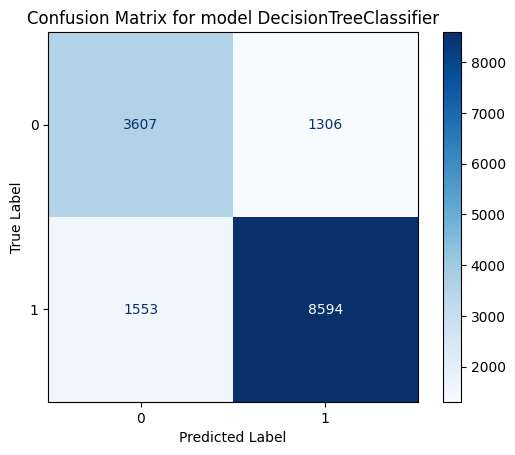

In [97]:
# Control the sample size using SMOTENC
# Determine the categorical feature indices
# Should already have categorical_feature_indices

# Calculate class size to be the sampling strategy
class_counts = y_train.value_counts()
majority_class_count = class_counts.max()
minority_class_count = class_counts.min()

# Set the desired minority class count to 75% of the majority class count
sampling_strategy = {
    class_counts.idxmin(): int(0.75 * majority_class_count),
    class_counts.idxmax(): majority_class_count
}

smotenc75 = SMOTENC(categorical_features=categorical_feature_indices, sampling_strategy=sampling_strategy, random_state=42)
X_train_smotenc75, y_train_smotenc75 = smotenc75.fit_resample(X_train, y_train)

# Train and plot CART model
cart_smotenc75 = train_CART_onehot_print_plot(X_train_smotenc75, X_test, y_train_smotenc75, y_test)

We can check them by printing the sample size:

In [98]:
# Count the occurrences of each class
(lambda counter: print(f"Number of 0s: {counter[0]}, Number of 1s: {counter[1]}"))(Counter(y_train))
(lambda counter: print(f"Number of 0s: {counter[0]}, Number of 1s: {counter[1]}"))(Counter(y_train_rus))
(lambda counter: print(f"Number of 0s: {counter[0]}, Number of 1s: {counter[1]}"))(Counter(y_train_ros))
(lambda counter: print(f"Number of 0s: {counter[0]}, Number of 1s: {counter[1]}"))(Counter(y_train_smotenc))
(lambda counter: print(f"Number of 0s: {counter[0]}, Number of 1s: {counter[1]}"))(Counter(y_train_smotenc75))

Number of 0s: 9782, Number of 1s: 20380
Number of 0s: 9782, Number of 1s: 9782
Number of 0s: 20380, Number of 1s: 20380
Number of 0s: 20380, Number of 1s: 20380
Number of 0s: 15285, Number of 1s: 20380


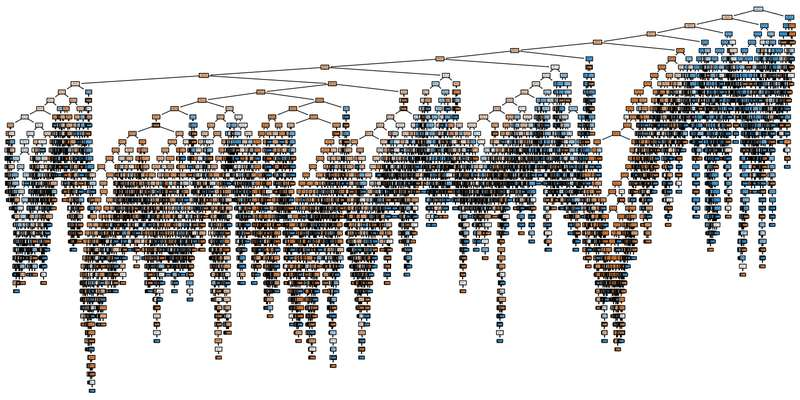

In [99]:
# Plot the tree, not necessary
# Very slow because the tree is too big
modelname = cart_smotenc75
plt.figure(figsize=(20,10))
plot_tree(modelname, 
          filled=True, 
          rounded=True, 
          class_names=list(map(str, modelname.classes_)))  # Update class names as appropriate)
plt.show()

## **4.** Random Forest & XGBoost

In this part, we will use the function in sklearn to perform the bagging and boosting. Specifically, we will use random forest and XGBoost. Let's go with random forest. Random forest accept only numerical data, we either need to do lable encoding or one hot encoding.

In [100]:
!pip install xgboost

In [101]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

Firstly, let's do one hot encoding. Note that the parameters X_train and X_test are changed into encoded ones.

In [102]:
# Identify categorical columns (assuming they are of type 'object')
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Apply one-hot encoding using pandas get_dummies; drop_first to avoid dummy variable trap.
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align the dataframes so they have the same columns; fill missing dummy columns with 0.
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Check whether one-hot encoding succeeded through the datatype
if X_train_encoded.select_dtypes(include=['object']).empty and X_test_encoded.select_dtypes(include=['object']).empty:
    X_train = X_train_encoded
    X_test = X_test_encoded

Accuracy: 0.8441
False Negative Rate (FNR): 0.12831378732630333 && False Positive Rate (FPR): 0.21290453897822104


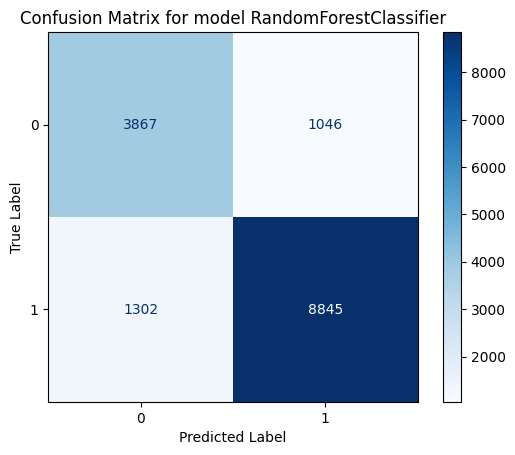

(0.12831378732630333, 0.21290453897822104)

In [103]:
# Define an Random Forest object using RandomForestClassifier 
rf_model = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42)

# Fit the model
rf_model.fit(X_train, y_train)
print_plot_confusion_matrix(rf_model,X_test,y_test)

### Feature importances

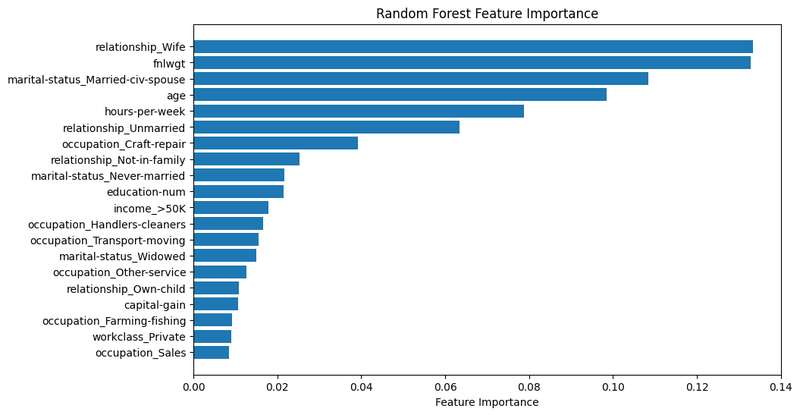

In [104]:
 # Get feature importances from the random forest model
feature_importances = rf_model.feature_importances_

# Get the names of features
feature_names = list(X_train.columns)

# Sort features based on importance and pick the first 20
sorted_idx = feature_importances.argsort()[-20:]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx], align="center")
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

Now try to use XGBoost.

You may need to install xgboost first:

$ pip install xgboost

Accuracy: 0.8522
False Negative Rate (FNR): 0.13284714693998226 && False Positive Rate (FPR): 0.1787095461021779


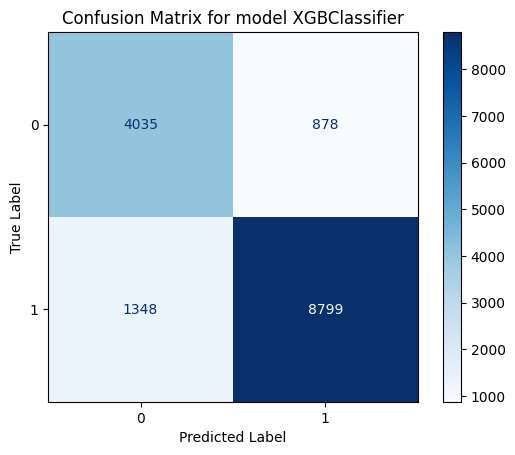

(0.13284714693998226, 0.1787095461021779)

In [105]:
# Defining and fitting XGBoost
xgbcls_model = XGBClassifier(n_estimators=100, random_state=42)
xgbcls_model.fit(X_train, y_train)
print_plot_confusion_matrix(xgbcls_model,X_test,y_test)

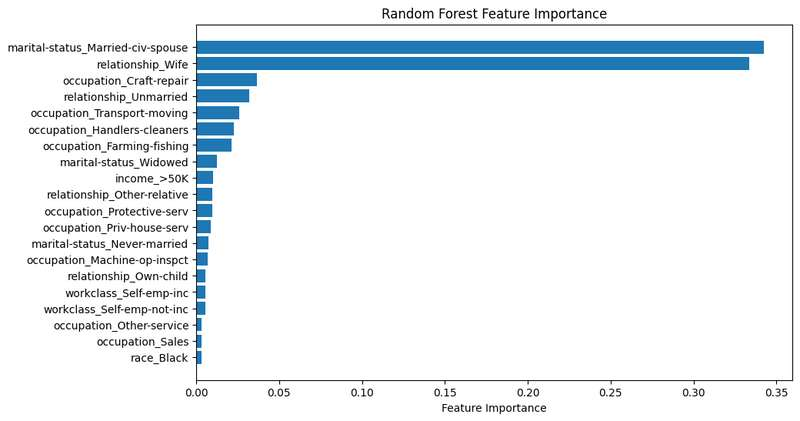

In [106]:
 # Get feature importances from the random forest model
feature_importances = xgbcls_model.feature_importances_

# Get the names of features
feature_names = list(X_train.columns)

# Sort features based on importance and pick the first 20
sorted_idx = feature_importances.argsort()[-20:]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx], align="center")
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

Let's start to check their bias and variance. You can directly use the following code to check complexities.

Note: It is a binary classfication task here. In this case, 0-1 loss is used as a substitute for measuring bias. If it is a regression task, you should directly calculate bias and variance.

*this part is very slow, you can reduce n_fold or delete some digit in n_estimator_list to make it faster.

In [107]:
def compute_accuracy_cv(X_model,X_train,y_train,n_fold=50):
    # Perform 50-fold cross-validation
    cv = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=8888)
    accuracy_scores = cross_val_score(X_model, X_train, y_train, cv=cv, scoring='accuracy')
    return np.mean(accuracy_scores),np.var(accuracy_scores,ddof=1)

In [108]:
meanAccList = []
varAccList = []
modelNameList = []

In [109]:
# This part is very slow
# Around 5 mins for each of the following 3 cell
n_estimator_list = [5,10,50,100,200]
for nEst in n_estimator_list:
    rf_model = RandomForestClassifier(n_estimators=nEst, max_features='sqrt', random_state=42)
    meanAcc, varAcc = compute_accuracy_cv(rf_model, X_train, y_train)
    meanAccList.append(meanAcc)
    varAccList.append(varAcc)
    modelNameList.append("RF_%d"%(nEst))

In [110]:
n_depth_list = [7,10,13,15,18]
for nDepth in n_depth_list:
    max_depth_cart = DecisionTreeClassifier(max_depth=nDepth)
    meanAcc, varAcc = compute_accuracy_cv(max_depth_cart, X_train, y_train)
    meanAccList.append(meanAcc)
    varAccList.append(varAcc)
    modelNameList.append("CART_%d"%(nDepth))

In [111]:
n_estimator_list = [5,10,50,100,200]
for nEst in n_estimator_list:
    xgbcls_model = XGBClassifier(n_estimators=nEst, random_state=42)
    meanAcc, varAcc = compute_accuracy_cv(xgbcls_model, X_train, y_train)
    meanAccList.append(meanAcc)
    varAccList.append(varAcc)
    modelNameList.append("XGB_%d"%(nEst))

In [112]:
# Create a DataFrame
df = pd.DataFrame({
    'meanAccList': meanAccList,
    'varAccList': varAccList,
    'modelNameList': modelNameList
})
# Access the bias via 1 - accuracy
df['meanAccList'] = 1 - df['meanAccList']

# Sort the DataFrame by meanAccList
df_sorted = df.sort_values(by='meanAccList')
# Create a manual range
df_sorted['manual_range'] = range(df_sorted.shape[0])

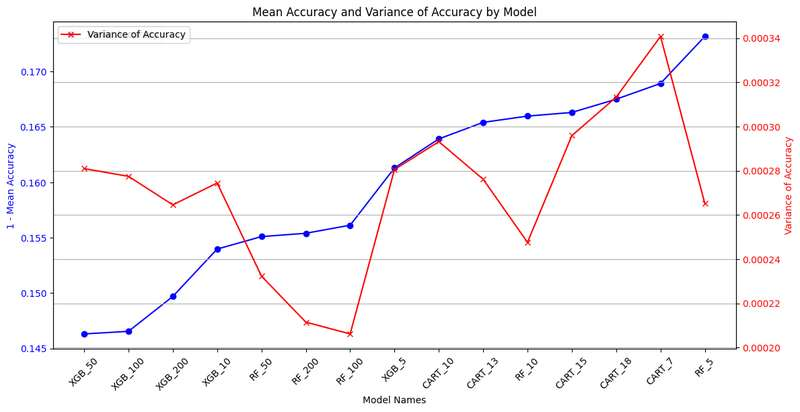

In [113]:
# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot mean accuracy on the primary y-axis
ax1.plot(df_sorted['manual_range'], df_sorted['meanAccList'], label='Mean Accuracy', marker='o', color='b')
ax1.set_xlabel('Model Names')
ax1.set_ylabel('1 - Mean Accuracy', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticks(df_sorted['manual_range'])
ax1.set_xticklabels(df_sorted['modelNameList'], rotation=45)

# Create a twin y-axis to plot variance
ax2 = ax1.twinx()
ax2.plot(df_sorted['manual_range'], df_sorted['varAccList'], label='Variance of Accuracy', marker='x', color='r')
ax2.set_ylabel('Variance of Accuracy', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Add legends
fig.tight_layout()  # Adjust layout to make room for x-tick labels
ax1.legend(loc='best')
ax2.legend(loc='best')

plt.title('Mean Accuracy and Variance of Accuracy by Model')
plt.grid(True)

plt.show()

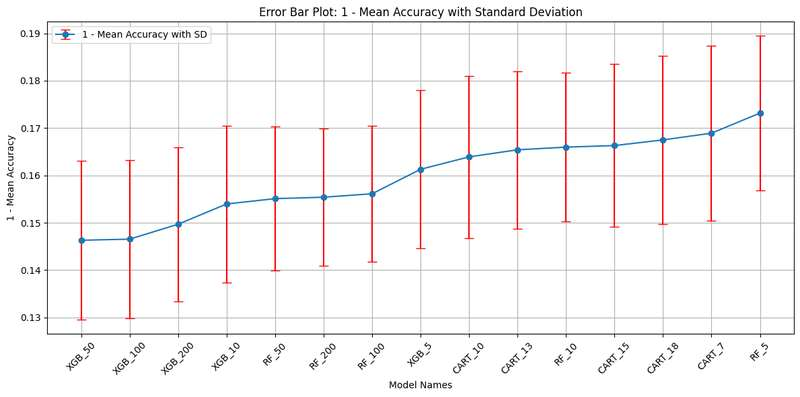

In [114]:
# Compute standard deviation from variance
df_sorted['stdAccList'] = np.sqrt(df_sorted['varAccList'])

# Create an error bar plot:
fig, ax = plt.subplots(figsize=(12, 6))

ax.errorbar(
    df_sorted['manual_range'], 
    df_sorted['meanAccList'], 
    yerr=df_sorted['stdAccList'], 
    fmt='o-', 
    ecolor='r', 
    capsize=5, 
    label='1 - Mean Accuracy with SD'
)

# Set the x-axis ticks and labels
ax.set_xticks(df_sorted['manual_range'])
ax.set_xticklabels(df_sorted['modelNameList'], rotation=45)
ax.set_xlabel('Model Names')
ax.set_ylabel('1 - Mean Accuracy')
ax.set_title('Error Bar Plot: 1 - Mean Accuracy with Standard Deviation')

ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

## **5.** Ensemble Modeling: Bagging, Stacking and Voting

Now we want to create our own ensemble models. We will try bagging with kNN model, and then try voting and stacking. 

*The following models are made for learning purposes. This does not mean that they are the best models for the dataset, nor does it mean that they have been optimized.

In [115]:
from sklearn.ensemble import BaggingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

Let's perform bagging with kNN model

In [116]:
# Define the kNN classifier
knn_model = KNeighborsClassifier(n_neighbors=5)

# Define the BaggingClassifier
bagging_model = BaggingClassifier(
    estimator=knn_model,
    n_estimators=100,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    bootstrap_features=False,
    random_state=42
)

# Fit the BaggingClassifier on the training data
bagging_model.fit(X_train, y_train)

# Predict on the test data
y_pred = bagging_model.predict(X_test)

# Compute the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.7142762284196548


Let's perform Voting

In [117]:
# Define the other classifiers
xgbcls_model = XGBClassifier(n_estimators=100, random_state=42)
max_depth_cart = DecisionTreeClassifier(max_depth=10)
rf_model = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42)

# Define the VotingClassifier
voting_model = VotingClassifier(
    estimators=[
        ('bagging', bagging_model),
        ('xgb', xgbcls_model),
        ('cart', max_depth_cart),
        ('rf', rf_model)
    ],
    voting='soft'  # Use 'soft' voting to use predicted probabilities
)

# Fit the VotingClassifier on the training data
voting_model.fit(X_train, y_train)

# Predict on the test data
y_pred = voting_model.predict(X_test)

# Compute the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Predict probabilities on the test data
y_pred_proba = voting_model.predict_proba(X_test)

# Print the predicted probabilities for the first few samples
print(f"Predicted Probabilities for the first few samples:\n{y_pred_proba[:5]}")

Accuracy: 0.8620185922974768
Predicted Probabilities for the first few samples:
[[0.41091477 0.58908523]
 [0.089048   0.910952  ]
 [0.06365761 0.93634239]
 [0.02573462 0.97426538]
 [0.51994475 0.48005525]]


Let's perform stacking

In [118]:
# Define the base models
base_models = [
    ('bagging', bagging_model),
    ('xgb', xgbcls_model),
    ('cart', max_depth_cart),
    ('rf', rf_model)
]

# Define the meta-model
meta_model = LogisticRegression(random_state=42)

# Define the StackingClassifier
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5)

# Fit the StackingClassifier on the training data
stacking_model.fit(X_train, y_train)

# Predict on the test data
y_pred = stacking_model.predict(X_test)

# Compute the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Predict probabilities on the test data
y_pred_proba = stacking_model.predict_proba(X_test)

# Print the predicted probabilities for the first few samples
print(f"Predicted Probabilities for the first few samples:\n{y_pred_proba[:5]}")

Accuracy: 0.8622841965471447
Predicted Probabilities for the first few samples:
[[0.29770452 0.70229548]
 [0.02799837 0.97200163]
 [0.02167489 0.97832511]
 [0.01391838 0.98608162]
 [0.56519507 0.43480493]]


# SUMMATIVE ASSESSMENT

Now pick a dataset of your choice. Please ensure your dataset is a csv file under 100MB named sem4_portfolio_5_data_custom.csv

Apply at least one resampling method, one pruned decision tree, and one self-created ensemble method to your dataset. 
Use any way you like to check at least one model for overfitting and underfitting. 
Make sure you are able to interpret all your results.

Note: Your model doesn't need to have great results at the end. But you need to be able to notice that.

### **Restart the Notebook to avoid error!!**

# Breast Cancer Dataset 
- Source: https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset

- I will use the dataset to predict wehther a breast mass is maligant or benign based on featured derived from FNA.
- Total of 569 samples, 30 numerical features
- Target variable == 'diagnosis' (binary)


### Focus of Analysis
1. Resampling - SMOTE to address the class imblance and improve prediction of maligant cases.
2. Apply Pruned Decision Tree to prevent overfitting to strong predictors like "radius_mean"
3. Voting Classifier combining Pruned Tree with other models = Random Forest, and KNN to enhance prediction - Self-created Ensemble Model
4. Overfitting/Underfitting Check using learning curves to evaluate Ensemble Model performance.

#### 0) Import libraries

In [46]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

In [47]:
# Define the print_plot_confusion_matrix function
def print_plot_confusion_matrix(modelname, X_test, y_test):
    predictions = modelname.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"Accuracy: {accuracy:.4f}")
    labels_confu = np.unique(np.concatenate((y_test, predictions)))
    cm = confusion_matrix(y_test, predictions, labels=labels_confu)
    TN, FP, FN, TP = cm.ravel()
    FNR = FN / (FN + TP)
    FPR = FP / (FP + TN)
    print("False Negative Rate (FNR):", FNR, "&& False Positive Rate (FPR):", FPR)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_confu)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for model {modelname.__class__.__name__}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    return FNR, FPR

#### 1) Loading the Data

In [48]:
# Load the Breast Cancer Dataset
df = pd.read_csv('sem4_portfolio_5_data_custom.csv')

# Display the first few rows to understand the dataset
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


#### 2) Exploring the Dataset

In [49]:
# Check the shape of the dataset
print("Dataset Shape:", df.shape)

# Display basic information about the dataset
df.info()

Dataset Shape: (569, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  p

In [50]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [51]:
# Display summary statistics of numerical features
print("Summary Statistics:\n", df.describe())

Summary Statistics:
                  id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064  

In [52]:
# Examine the class distribution of the target variable 'diagnosis'
print("Class Distribution of Diagnosis:\n", df['diagnosis'].value_counts())

# Calculate the percentage of each class
class_percentages = df['diagnosis'].value_counts(normalize=True) * 100
print("\nClass Distribution (Percentage):\n", class_percentages)

Class Distribution of Diagnosis:
 diagnosis
B    357
M    212
Name: count, dtype: int64

Class Distribution (Percentage):
 diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


Class Distribution of Diagnosis:
 diagnosis
B    357
M    212
Name: count, dtype: int64

Class Distribution (Percentage):
 diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


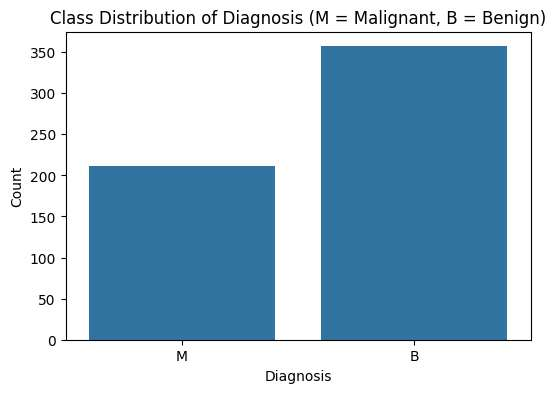

In [53]:
# Examine the class distribution of the target variable 'diagnosis'
print("Class Distribution of Diagnosis:\n", df['diagnosis'].value_counts())

# Calculate the percentage of each class
class_percentages = df['diagnosis'].value_counts(normalize=True) * 100
print("\nClass Distribution (Percentage):\n", class_percentages)

# Visualize the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df)
plt.title("Class Distribution of Diagnosis (M = Malignant, B = Benign)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

#### 3) Data Pre-processing

Drop irrelvant features

In [54]:
# Drop the 'id' column if it exists
if 'id' in df.columns:
    df = df.drop('id', axis=1)
    print("Dropped 'id' column.")
else:
    print("No 'id' column found in the dataset.")

# Encode the target variable: M (malignant) → 1, B (benign) → 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Display the first few rows to confirm changes
print("First few rows after encoding 'diagnosis':\n", df.head())

Dropped 'id' column.
First few rows after encoding 'diagnosis':
    diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst 

Split the dataset into X and Y

In [55]:
# Split the dataset into features (X) and target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Verify data types to ensure all features are numerical
print("Feature Data Types:\n", X.dtypes)

# Display the first few rows of the features to confirm
print("\nFirst few rows of features (X):\n", X.head())

Feature Data Types:
 radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst       float64

In [56]:
# Verify the target encoding
print("Target (y) Distribution After Encoding:\n", Counter(y))

Target (y) Distribution After Encoding:
 Counter({0: 357, 1: 212})


#### 4) Resampling - SMOTE
- Balancing the classes for 'maligant cases'.

In [57]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and test sets
print("Training Set Shape (X_train, y_train):", X_train.shape, y_train.shape)
print("Test Set Shape (X_test, y_test):", X_test.shape, y_test.shape)

Training Set Shape (X_train, y_train): (455, 30) (455,)
Test Set Shape (X_test, y_test): (114, 30) (114,)


Check class Distribution before resampling

Class Distribution Before Resampling (Training Set):
 Counter({0: 286, 1: 169})

Class Distribution Before Resampling (Percentage):
 diagnosis
0    62.857143
1    37.142857
Name: proportion, dtype: float64


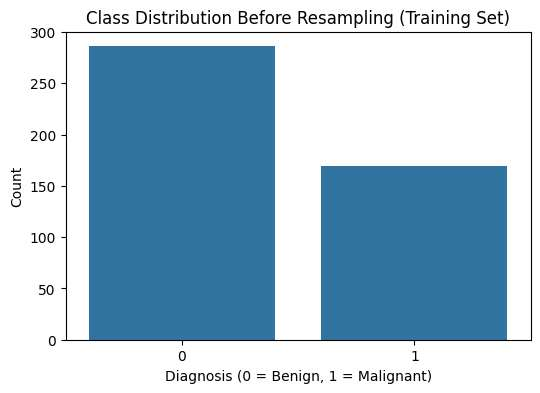

In [58]:
# Check the class distribution before resampling
print("Class Distribution Before Resampling (Training Set):\n", Counter(y_train))

# Calculate the percentage of each class in the training set
class_percentages_before = pd.Series(y_train).value_counts(normalize=True) * 100
print("\nClass Distribution Before Resampling (Percentage):\n", class_percentages_before)

# Visualize the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title("Class Distribution Before Resampling (Training Set)")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Count")
plt.show()

Apply SMOTE

Class Distribution After SMOTE (Training Set):
 Counter({0: 286, 1: 286})

Class Distribution After SMOTE (Percentage):
 diagnosis
0    50.0
1    50.0
Name: proportion, dtype: float64


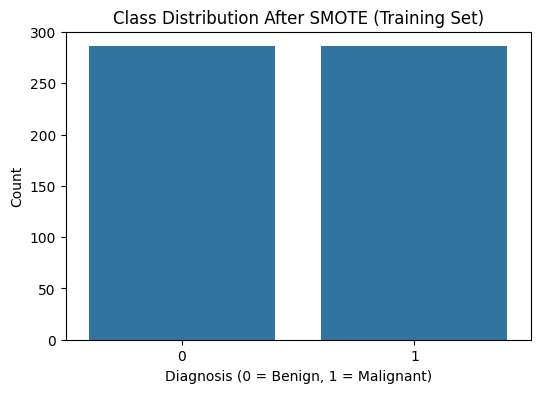

In [59]:
# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check the class distribution after SMOTE
print("Class Distribution After SMOTE (Training Set):\n", Counter(y_train_smote))

# Calculate the percentage of each class after SMOTE
class_percentages_smote = pd.Series(y_train_smote).value_counts(normalize=True) * 100
print("\nClass Distribution After SMOTE (Percentage):\n", class_percentages_smote)

# Visualize the class distribution after SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_smote)
plt.title("Class Distribution After SMOTE (Training Set)")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Count")
plt.show()

Apply Undersampling

Class Distribution After Undersampling (Training Set):
 Counter({0: 169, 1: 169})

Class Distribution After Undersampling (Percentage):
 diagnosis
0    50.0
1    50.0
Name: proportion, dtype: float64


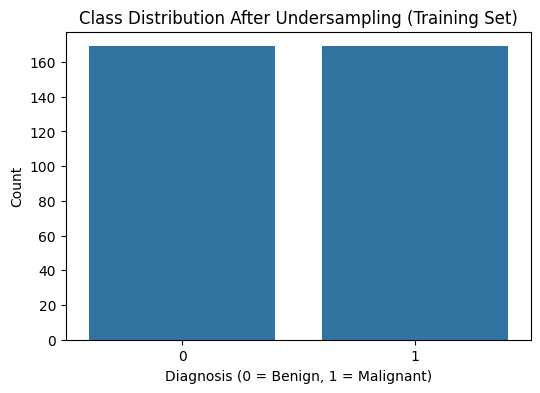

In [60]:
# Apply undersampling to the training data
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

# Check the class distribution after undersampling
print("Class Distribution After Undersampling (Training Set):\n", Counter(y_train_under))

# Calculate the percentage of each class after undersampling
class_percentages_under = pd.Series(y_train_under).value_counts(normalize=True) * 100
print("\nClass Distribution After Undersampling (Percentage):\n", class_percentages_under)

# Visualize the class distribution after undersampling
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_under)
plt.title("Class Distribution After Undersampling (Training Set)")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Count")
plt.show()

Evaluate Resampling Impact

Performance on Original Data:
Accuracy: 0.9474
False Negative Rate (FNR): 0.06976744186046512 && False Positive Rate (FPR): 0.04225352112676056


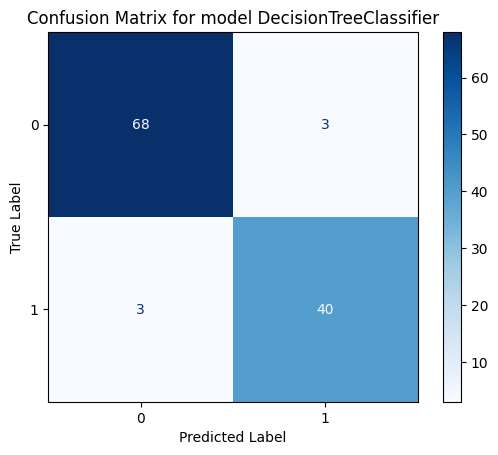

Performance on SMOTE-Resampled Data:
Accuracy: 0.9298
False Negative Rate (FNR): 0.046511627906976744 && False Positive Rate (FPR): 0.08450704225352113


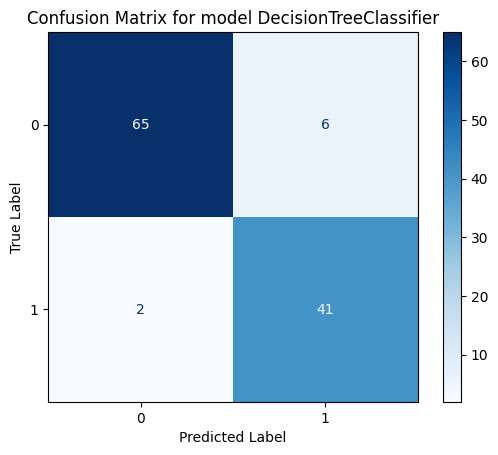

Performance on Undersampled Data:
Accuracy: 0.9561
False Negative Rate (FNR): 0.046511627906976744 && False Positive Rate (FPR): 0.04225352112676056


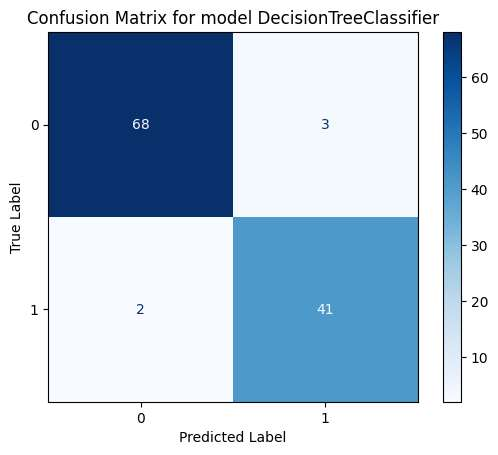

In [61]:
# Train a decision tree on the original training data
dt_original = DecisionTreeClassifier(random_state=42)
dt_original.fit(X_train, y_train)
print("Performance on Original Data:")
fpr_original, fnr_original = print_plot_confusion_matrix(dt_original, X_test, y_test)

# Train a decision tree on the SMOTE-resampled training data
dt_smote = DecisionTreeClassifier(random_state=42)
dt_smote.fit(X_train_smote, y_train_smote)
print("Performance on SMOTE-Resampled Data:")
fpr_smote, fnr_smote = print_plot_confusion_matrix(dt_smote, X_test, y_test)

# Train a decision tree on the undersampled training data
dt_under = DecisionTreeClassifier(random_state=42)
dt_under.fit(X_train_under, y_train_under)
print("Performance on Undersampled Data:")
fpr_under, fnr_under = print_plot_confusion_matrix(dt_under, X_test, y_test)

#### 5) Pruned Decision Tree

Train a Pruned Decision Tree

In [62]:
# Train a pruned decision tree on the SMOTE-resampled data
pruned_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
pruned_tree.fit(X_train_smote, y_train_smote)
print("Pruned Decision Tree trained with max_depth=5 on SMOTE-resampled data.")

Pruned Decision Tree trained with max_depth=5 on SMOTE-resampled data.


Evaluate the Pruned Decision Tree

Performance of Pruned Decision Tree:
Accuracy: 0.9561
False Negative Rate (FNR): 0.06976744186046512 && False Positive Rate (FPR): 0.028169014084507043


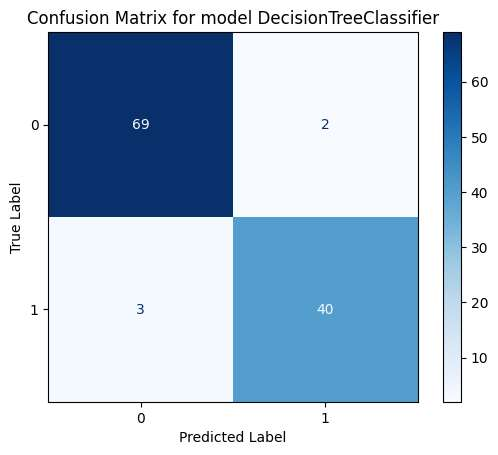

In [63]:
# Evaluate the pruned decision tree
print("Performance of Pruned Decision Tree:")
fpr_pruned, fnr_pruned = print_plot_confusion_matrix(pruned_tree, X_test, y_test)

Pruned Deicion Tree

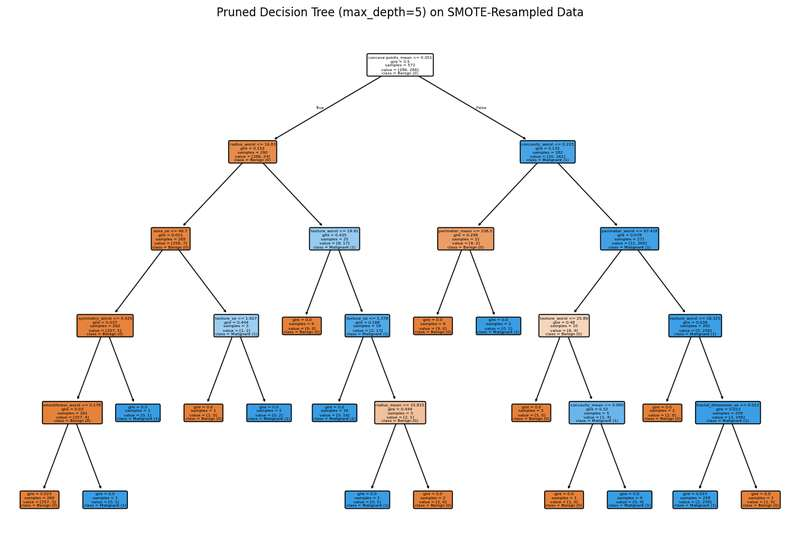

In [64]:
# Step 5.3: Visualize the pruned decision tree
plt.figure(figsize=(15, 10))
plot_tree(pruned_tree, feature_names=X.columns, class_names=['Benign (0)', 'Malignant (1)'], filled=True, rounded=True)
plt.title("Pruned Decision Tree (max_depth=5) on SMOTE-Resampled Data")
plt.show()

#### 6) Self-Created Ensemble Method
- Voting classifiers that combines the pruned decision tree with models like Random Forest and kNN.
- Train the ensemble on the SMOTE-resampled data, as it provided a balanced and larger dataset, compared to undersamping. 

Define and Train Ensemble

In [65]:
# Define and train a custom ensemble (Voting Classifier)
# Use the pruned tree along with Random Forest and kNN
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Create a voting classifier combining the pruned tree, Random Forest, and kNN
voting_ensemble = VotingClassifier(
    estimators=[
        ('pruned_tree', pruned_tree),
        ('rf', rf_model),
        ('knn', knn_model)
    ],
    voting='soft'  # Use soft voting to consider predicted probabilities
)

# Train the ensemble on the SMOTE-resampled data
voting_ensemble.fit(X_train_smote, y_train_smote)
print("Custom Voting Ensemble trained on SMOTE-resampled data.")

Custom Voting Ensemble trained on SMOTE-resampled data.


Evaluate the Ensemble

Performance of Custom Voting Ensemble:
Accuracy: 0.9737
False Negative Rate (FNR): 0.046511627906976744 && False Positive Rate (FPR): 0.014084507042253521


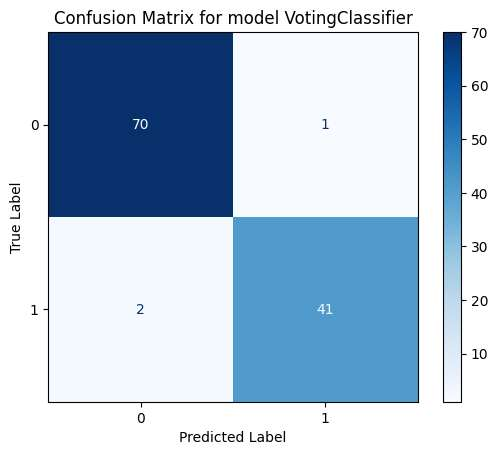

In [66]:
# Evaluate the custom ensemble
print("Performance of Custom Voting Ensemble:")
fpr_ensemble, fnr_ensemble = print_plot_confusion_matrix(voting_ensemble, X_test, y_test)

Compare and Interpret Results

In [67]:
# Compare the ensemble's performance to the pruned tree
print("Comparison of Pruned Decision Tree vs. Custom Voting Ensemble:")
print(f"Pruned Tree - Accuracy: {pruned_tree.score(X_test, y_test):.4f}, FNR: {fnr_pruned:.4f}, FPR: {fpr_pruned:.4f}")
print(f"Ensemble    - Accuracy: {voting_ensemble.score(X_test, y_test):.4f}, FNR: {fnr_ensemble:.4f}, FPR: {fpr_ensemble:.4f}")

# Interpretation
print("\nInterpretation:")
if voting_ensemble.score(X_test, y_test) > pruned_tree.score(X_test, y_test):
    print("- The ensemble improved accuracy over the pruned tree, likely due to combining the strengths of multiple models.")
else:
    print("- The ensemble did not improve accuracy over the pruned tree, possibly due to the pruned tree already performing well.")
if fnr_ensemble < fnr_pruned:
    print("- The ensemble reduced the FNR, improving detection of malignant cases, which is critical for medical diagnosis.")
else:
    print("- The ensemble did not reduce the FNR compared to the pruned tree, indicating no improvement in detecting malignant cases.")
if fpr_ensemble > fpr_pruned:
    print("- The ensemble increased the FPR, reflecting a trade-off for better minority class detection.")
else:
    print("- The ensemble reduced or maintained the FPR, avoiding more false positives.")

Comparison of Pruned Decision Tree vs. Custom Voting Ensemble:
Pruned Tree - Accuracy: 0.9561, FNR: 0.0282, FPR: 0.0698
Ensemble    - Accuracy: 0.9737, FNR: 0.0141, FPR: 0.0465

Interpretation:
- The ensemble improved accuracy over the pruned tree, likely due to combining the strengths of multiple models.
- The ensemble reduced the FNR, improving detection of malignant cases, which is critical for medical diagnosis.
- The ensemble reduced or maintained the FPR, avoiding more false positives.


#### 7) Check for Overfitting and Underfitting

Learning Curves

In [68]:
# Generate learning curves for the voting ensemble
train_sizes, train_scores, test_scores = learning_curve(
    voting_ensemble, 
    X_train_smote, 
    y_train_smote, 
    cv=5, 
    n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

# Calculate mean and standard deviation of training and test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

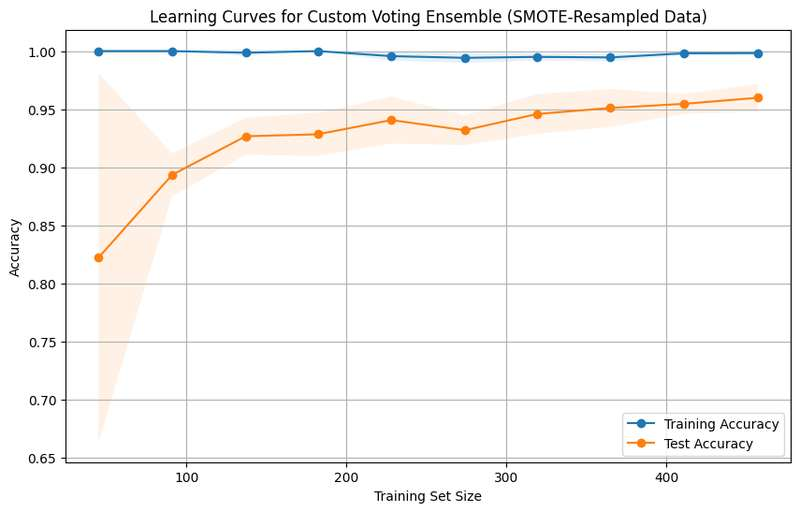

In [69]:
# Plot the learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Accuracy', marker='o')
plt.plot(train_sizes, test_mean, label='Test Accuracy', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curves for Custom Voting Ensemble (SMOTE-Resampled Data)')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [70]:
# Interpret the learning curves
print("Interpretation of Learning Curves:")
if train_mean[-1] > test_mean[-1] + 0.05:  # Check for a significant gap
    print("- There is a large gap between training and test accuracy (training: {:.4f}, test: {:.4f}), indicating overfitting.".format(train_mean[-1], test_mean[-1]))
    print("- The ensemble may be too complex, fitting the training data too closely.")
elif train_mean[-1] < 0.7 and test_mean[-1] < 0.7:  # Check for low performance
    print("- Both training and test accuracy are low (training: {:.4f}, test: {:.4f}), indicating underfitting.".format(train_mean[-1], test_mean[-1]))
    print("- The ensemble may be too simple to capture the patterns in the data.")
else:
    print("- Training and test accuracy are close (training: {:.4f}, test: {:.4f}), indicating a good fit.".format(train_mean[-1], test_mean[-1]))
    print("- The ensemble generalizes well to unseen data.")
if test_mean[-1] > test_mean[0]:
    print("- Test accuracy increases as the training set size grows, showing the model benefits from more data.")
else:
    print("- Test accuracy is flat or decreasing, suggesting the model may not benefit from more data.")

Interpretation of Learning Curves:
- Training and test accuracy are close (training: 0.9982, test: 0.9598), indicating a good fit.
- The ensemble generalizes well to unseen data.
- Test accuracy increases as the training set size grows, showing the model benefits from more data.


#### 8) Summary and Interpretations

In [71]:
# Summarize performance metrics from previous steps
print("Summary of Performance Metrics Across Steps:")
print("\nStep 4.5: Resampling Evaluation (Unpruned Decision Tree)")
print(f"Original Data    - Accuracy: 0.9474, FNR: 0.0698, FPR: 0.0423")
print(f"SMOTE-Resampled  - Accuracy: 0.9298, FNR: 0.0465, FPR: 0.0845")
print(f"Undersampled     - Accuracy: 0.9561, FNR: 0.0465, FPR: 0.0423")

print("\nStep 5: Pruned Decision Tree (max_depth=5, SMOTE-Resampled)")
print(f"Pruned Tree      - Accuracy: {pruned_tree.score(X_test, y_test):.4f}, FNR: {fnr_pruned:.4f}, FPR: {fpr_pruned:.4f}")

print("\nStep 6: Custom Voting Ensemble (SMOTE-Resampled)")
print(f"Voting Ensemble  - Accuracy: {voting_ensemble.score(X_test, y_test):.4f}, FNR: {fnr_ensemble:.4f}, FPR: {fpr_ensemble:.4f}")

print("\nStep 7: Overfitting/Underfitting Check (Learning Curves)")
print(f"Final Training Accuracy: {train_mean[-1]:.4f}")
print(f"Final Test Accuracy: {test_mean[-1]:.4f}")

Summary of Performance Metrics Across Steps:

Step 4.5: Resampling Evaluation (Unpruned Decision Tree)
Original Data    - Accuracy: 0.9474, FNR: 0.0698, FPR: 0.0423
SMOTE-Resampled  - Accuracy: 0.9298, FNR: 0.0465, FPR: 0.0845
Undersampled     - Accuracy: 0.9561, FNR: 0.0465, FPR: 0.0423

Step 5: Pruned Decision Tree (max_depth=5, SMOTE-Resampled)
Pruned Tree      - Accuracy: 0.9561, FNR: 0.0282, FPR: 0.0698

Step 6: Custom Voting Ensemble (SMOTE-Resampled)
Voting Ensemble  - Accuracy: 0.9737, FNR: 0.0141, FPR: 0.0465

Step 7: Overfitting/Underfitting Check (Learning Curves)
Final Training Accuracy: 0.9982
Final Test Accuracy: 0.9598
